In [31]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from PIL import Image
import os
import resource
import shutil
resource.getrusage(resource.RUSAGE_SELF)[2]/1024

150.70703125

# Setting Up

## Most Basic: Functions and Variables

Recall that the T matrices are not causal. You do not have a simple physical input-output relation. You need to know the future in order to be able to use them. Meanwhile, the S matrices are causal: you give input fields anf get output fields.

The refraction plane is the x-z plane, i.e. an s-polarised wave has the E field pointing along y and a p-polarised wave has the E field pointing along x.

In [2]:
epsilon_0 = 1 #8.854E-12 # F/m
mu_0 = 1 #np.pi*4.0E-7 # H/m
c = 1 #3.0E08 # m/s
lam0 = 450e-9+0.0j
#h0 = h1
theta0 = np.pi/6
h1 = 10e-9
n0 = 1.0+0.0j
n1 = 1.5+0.0j
e_x = np.array([1.0,0.0,0.0])
e_y = np.array([0.0,1.0,0.0])
e_z = np.array([0.0,0.0,1.0])
mirror_s = np.array([[1.0+0.0j,1.0e-9+0.0j],[1.0e-9+0.0j,1.0+0.0j]])
colors = ['b','orange','purple']

def MtoS(mat):  # to scattering matrix, diagonal terms are reflection coefficients.
    [[m11,m12],[m21,m22]]=mat
    [[r12,t21],[t12,r21]]=[[-m21/m22,1/m22],[m11-m12*m21/m22,m12/m22]]
    return np.array([[r12,t21],[t12,r21]])

def StoM(co):  # to transfer matrix, 
    [[r12,t21],[t12,r21]]=co
    [[m11,m12],[m21,m22]]=[[(t12- r12*r21/t21),r21/t21],[-r12/t21,1/t21]]
    return np.array([[m11,m12],[m21,m22]])

def totalSM(layers):
    t=np.identity(2)
    for lay in layers:
        t0=StoM(lay)
        t=t0@t
    s=MtoS(t)
    return s,t

def delete_content(str_folder_name):
    !rm $str_folder_name/* 

## EM Wave

In [3]:
def k_vector(k_mag,theta=0):
    k_vec = k_mag*np.array([np.sin(theta),0,np.cos(theta)])
    return k_vec

def k_vector_multi(k_values,theta=0):
    k_vecs = k_values[:,np.newaxis]*np.array([np.sin(theta),0,np.cos(theta)])
    return k_vecs
               
def k_j(ki,ni,nj):
    kj = np.array([ki[0],ki[1],np.sqrt(ki[2]**2+np.dot(ki,ki.conj())*((nj/ni)**2-1))])
    return kj

def gen_E_amp(E_par,E_perp):
    if E_par == 0 and E_perp == 0:
        return np.array([complex(E_par),complex(E_perp),0.0+0.0j])
    else:
        return 1/np.sqrt(np.abs(E_par)**2+np.abs(E_perp)**2)*np.array([complex(E_par),complex(E_perp),0.0+0.0j])

def E_avi_decomp(E_avi,ki):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(e_y,ki/np.sqrt(np.dot(ki,ki)))
    #proper_E_avi = E_avsi + E_avpi
    return E_avsi,E_avpi

def mag_field(k_values, E_3d_k,theta=0):
    u_dir = np.array([np.sin(theta),0,np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    return -1 / (mu_0 * c) * np.einsum('i,ik->ik',1/k_values,np.cross(ki3ds, E_3d_k))

def mag_field_rev(k_values, E_3d_k,theta=0):
    u_dir = np.array([np.sin(theta),0,-np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    return -1 / (mu_0 * c) * np.einsum('i,ik->ik',1/k_values,np.cross(ki3ds, E_3d_k))

ki0 = k_vector(np.array(2*np.pi/lam0),theta0)

## System

### Elements and Periods

In [4]:
def medium(k_vec,h):  # scattering matrix, diagonal terms are reflection coefficients.
    # k_vec is a 3D vector
    rij=0
    rji=0
    tij=np.exp(1j*k_vec[2]*h)
    tji=np.exp(1j*k_vec[2]*h)
    return np.array([[rij,tji],[tij,rji]])

def interface_s(ki,kj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = kj[2]
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    # print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_p(ki,kj):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = kj[2]
    ki_a = np.sqrt(np.dot(ki,ki.conj()))
    kj_a = np.sqrt(np.dot(kj,kj.conj()))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi/ki_a**2 - kzj/kj_a**2)/(kzi/ki_a**2 + kzj/kj_a**2)
    rji = -rij
    tij = 2*kzi/((kj_a/ki_a)*kzi + (ki_a/kj_a)*kzj)
    tji = kzj/kzi * tij # 2*kzj/((ni/nj)*kzj + (nj/ni)*kzi)
    # print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def m_p(ki,kj,hi,hj):
    layers_p =[medium(ki,hi/2),interface_p(ki,kj),medium(kj,hj),interface_p(kj,ki),medium(ki,hi/2)]
    sp,mp = totalSM(layers_p) 
    #print(np.abs(sp[0][0])**2+np.abs(sp[0][1])**2)
    #print(np.abs(sp[1][0])**2+np.abs(sp[1][1])**2)
    return sp,mp,layers_p

def m_s(ki,kj,hi,hj):
    layers_s =[medium(ki,hi/2),interface_s(ki,kj),medium(kj,hj),interface_s(kj,ki),medium(ki,hi/2)]
    ss,ms = totalSM(layers_s)
    #print(np.abs(ss[0][0])**2+np.abs(ss[0][1])**2)
    #print(np.abs(ss[1][0])**2+np.abs(ss[1][1])**2)
    return ss,ms,layers_s

### Effectives

In [5]:
def eff_n(ki,perM,hi,hj):
    evs = np.linalg.eig(perM)[0]
    kz = np.log(evs[0])/(1j*(hi+hj))
    neff = np.real(np.sqrt((ki[0]**2+ki[1]**2+kz**2)/np.dot(ki,ki.conj())))
    return neff

def reverse_eff_n(ki,neff,hi,hj):
    n_s = 0
    n_p = 0
    def find_n_s(n):
        return eff_n(ki,m_s(ki,k_j(ki,n0,n),hi,hj)[1],hi,hj)-neff
    n_s = root_scalar(find_n_s, bracket=[1,2*neff]).root
    def find_n_p(n):
        return eff_n(ki,m_p(ki,k_j(ki,n0,n),hi,hj)[1],hi,hj)-neff
    n_p = root_scalar(find_n_p, bracket=[1,2*neff]).root
    return n_s,n_p

def reverse_eff_nh(ki,neff,n,h):
    r_s = 0
    r_p = 0
    def find_rs(r):
        return eff_n(ki,m_s(ki,k_j(ki,n0,n),r*h,(1-r)*h)[1],r*h,(1-r)*h)-neff
    r_s = root_scalar(find_rs, bracket=[0,1]).root
    def find_rp(r):
        return eff_n(ki,m_p(ki,k_j(ki,n0,n),r*h,(1-r)*h)[1],r*h,(1-r)*h)-neff
    r_p = root_scalar(find_rp, bracket=[0,1]).root
    return r_s,r_p

### Composite Structure

In [27]:
def element_maker(ki,refrac_indices,widths,width_ratios):
    elementss = []
    elementss_decomp = []
    #elementsp = []
    #elementsp_decomp = []
    #neffs = []
    #neffp = []
    for i in range(len(refrac_indices)):
        kj = k_j(ki,n0,refrac_indices[i])
        hi = width_ratios[i]*widths[i]
        hj = (1-width_ratios[i])*widths[i]
        ss,ms,layers_s = m_s(ki,kj,hi,hj)
        #nes = eff_n(ki,ms,hi,hj)
        #sp,mp,layers_p = m_p(ki,kj,hi,hj)
        #nep = eff_n(ki,mp,hi,hj)
        elementss.append(ss)
        #elementsp.append(sp)
        elementss_decomp.append(layers_s)
        #elementsp_decomp.append(layers_p)
        #neffs.append(nes)
        #neffp.append(nep)
    return elementss,elementss_decomp #,neffs,elementsp,elementsp_decomp,neffp

def embedded_structure(elements_s_form,num_elements):
    emb = 0
    for i in range(len(elements_s_form)):
        if i == 0:
            emb = np.tile(elements_s_form[i], (num_elements[i], 1, 1))
        else:
            emb = np.concatenate((emb, np.tile(elements_s_form[i], (num_elements[i], 1, 1))))
    return emb

## Fields

In [126]:
def M_eff(mMat):
    U_T = np.linalg.eig(mMat)[1]
    if np.abs(U_T[0][0]) > np.abs(U_T[1][0]):
        return U_T
    else:
        return np.array([U_T[1],U_T[0]])
    
def amps_from_emb_pol(a0_pol,emb):
    anbn_pol = np.array(M_eff(StoM(mirror_s))[0])
    #anbn_pol = np.array([1.0+0.0j,1.0+0.0j])
    aibi_pol = np.empty((len(emb)+1,2),dtype=np.complex64)
    aibi_pol[-1] = anbn_pol
    m = np.eye(2)
    for i in range(len(emb)-1,-1,-1):
        m = np.linalg.inv(StoM(emb[i]))@m
        aibi_pol[i] = m@(anbn_pol)
    return np.transpose(aibi_pol/aibi_pol[0][0]*np.abs(a0_pol))

def amps_from_emb_pol_multi_k(a0_pol,k_values,refrac_indices,widths,width_ratios,num_elements,decomp_factor=5,theta=0):
    ai_pol_k = np.empty((len(k_values),decomp_factor*np.sum(num_elements)+1),dtype=np.complex64)
    bi_pol_k = np.empty((len(k_values),decomp_factor*np.sum(num_elements)+1),dtype=np.complex64)
    for i in range(len(k_values)):
        ki = k_vector(k_values[i],theta) #elementss,elementss_decomp,neffs,elementsp,elementsp_decomp,neffp
        elementss_decomp = element_maker(ki,refrac_indices,widths,width_ratios)[1]
        embs = embedded_structure(elementss_decomp,num_elements)
        [ai_pol,bi_pol] = amps_from_emb_pol(a0_pol,embs)
        ai_pol_k[i,:] = ai_pol
        bi_pol_k[i,:] = bi_pol
    return ai_pol_k,bi_pol_k

def gaussian_weighting(k_values, k_c=5, sigma=1.5):
    return 1/(np.sqrt(2*np.pi)*sigma)*np.exp(-0.5 * ((k_values - k_c) / sigma)**2)

def time_mod(k_values, t_values):
    return np.exp(-1j * np.outer(k_values, t_values) * c)

def mag_field_t(ai_3d_multi_tk,bi_3d_multi_tk,theta=0):
    au_dir = (np.array([np.sin(theta),0,np.cos(theta)],dtype=np.complex64))
    bu_dir = (np.array([np.sin(theta),0,-np.cos(theta)],dtype=np.complex64))
    Hi_3d_multi_t = np.empty((np.shape(ai_3d_multi_tk)[0],np.shape(ai_3d_multi_tk)[2],np.shape(ai_3d_multi_tk)[3]),dtype=np.complex64)
    for t in range(np.shape(Hi_3d_multi_t)[0]):
        for p in range(np.shape(Hi_3d_multi_t)[1]):
            Hi_3d_multi_t[t][p] = np.sum(np.cross(au_dir,ai_3d_multi_tk[t][:,p])+np.cross(bu_dir,bi_3d_multi_tk[t][:,p]),axis=0)
    return -1 /(mu_0*c) * Hi_3d_multi_t

def sto3d_multi_tk(ai_pol_tk):
    return np.einsum('jkl,i->jkli', ai_pol_tk, e_y)

def amps_fields_from_emb_pol_multi_tk(a0_pol,k_values,t_values,refrac_indices,widths,width_ratios,num_elements,decomp_factor=5,theta=0,k_c=5,sigma=1.5):
    weights_tk = np.transpose(gaussian_weighting(k_values[:,np.newaxis],k_c,sigma)*time_mod(k_values,t_values))
    ai_pol_k,bi_pol_k = amps_from_emb_pol_multi_k(a0_pol,k_values,refrac_indices,widths,width_ratios,num_elements,decomp_factor,theta)
    norm = np.sum(gaussian_weighting(k_values[:,np.newaxis],k_c,sigma))
    ai_pol_tk = np.einsum('ij,jk->ijk',weights_tk,ai_pol_k)/norm
    bi_pol_tk = np.einsum('ij,jk->ijk',weights_tk,bi_pol_k)/norm
    ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
    bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
    ai_pol_t = np.sum(ai_pol_tk,axis=1)
    bi_pol_t = np.sum(bi_pol_tk,axis=1)
    Ei_3d_t = np.sum(ai_3d_multi_tk+bi_3d_multi_tk,axis=1)
    Hi_3d_t = mag_field_t(ai_3d_multi_tk,bi_3d_multi_tk,theta)
    return ai_pol_t,bi_pol_t,Ei_3d_t,Hi_3d_t

def plot_amps(ai,bi,time,num_elements,cols=colors,top_y=1,bottom_y=0):
    plt.figure()
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,edges[-1],1)
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'Intensity Across Layers t = {time} time units')
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.plot(xvals,np.abs(ai)**2, label='|a|^2')
    plt.plot(xvals,np.abs(bi)**2, label='|b|^2')
    plt.plot(xvals,np.abs(ai+bi)**2, label='|a+b|^2')
    plt.ylim(-0.02,1.02)
    plt.legend()
    plt.grid()
    plt.show()

## Momentum

In [8]:
def stress_tensor(Ei_3d,Hi_3d): # We always evaluate in vacuum
    E_ij = 0.5 * epsilon_0 * (np.tensordot((Ei_3d).conj(),(Ei_3d),axes=0) \
                              + np.tensordot((Ei_3d),(Ei_3d).conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot((Ei_3d).conj(),(Ei_3d)) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot((Hi_3d).conj(),(Hi_3d),axes=0) \
            + np.tensordot((Hi_3d),(Hi_3d).conj(),axes=0)) - \
            0.5 * mu_0 * np.dot((Hi_3d).conj(),(Hi_3d)) * np.eye(3)
    return E_ij + H_ij

def stress_tensor_t(Ei_3d_t,Hi_3d_t):
    t_len,pos_len = np.shape(Ei_3d_t)[:2]
    st_pol_t_pos = np.empty((t_len,pos_len,3,3),dtype=np.complex64)
    for t in range(t_len):
        for p in range(pos_len):
            st_pol_t_pos[t][p] = stress_tensor(Ei_3d_t[t][p],Hi_3d_t[t][p])
    return st_pol_t_pos

def z_momentum_flux(stress_tensor_tp):
    return np.real(np.einsum("jklm,l,m->jk",stress_tensor_tp,e_z,e_z))

def plot_z_momentum(z_momentum_flux, time, num_elements):
    int_locs = np.cumsum(np.array(num_elements))[:-1]
    plt.figure()
    p = plt.subplot(1,1,1)
    p.set_xlabel('Layer Number')
    p.set_ylabel('Z-Force Density')
    p.set_title(f'Z-Force Density Across Layers t = {time} time units')
    p.plot(np.diff(z_momentum_flux))
    for loc in int_locs:
        p.axvline(loc,ls='--',c='k')
    p.grid()
    return p

def plot_z_force_density(z_mom_flux_pos,time,num_elements,vals0,top_y=1,bottom_y=-0.6):
    plt.figure()
    f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(f_dens_pos),1)
    edgelocs = np.array([0, num_elements[0]-0.5])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i]-0.5,edges[i]-0.5+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=colors[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc-0.5,ls='--',c='k')
    plt.xlabel('Layer Number')
    plt.ylabel('Force Density')
    plt.title(f'Z-Force Density Across Layers t = {time} time units')
    plt.plot(xvals,f_dens_pos,label='Z-Force Density')
    plt.plot(xvals,vals0,label= f'Total Impulse at t = {time} time units')
    plt.ylim(-0.62,1.02)
    plt.legend(loc='upper left')
    plt.grid()
    vals0+=f_dens_pos
    plt.show()
    return vals0

## Forces on Interfaces

In [9]:
def surface_charges_currents_t(Ei_3d_t,Hi_3d_t,num_elements,refrac_indices):
    indices_to_remove = np.arange(0, Ei_3d_t.shape[1], 5)
    Di_3d_t_ints = np.delete(Ei_3d_t, indices_to_remove, axis=1)
    Ei_3d_t_ints = np.delete(Ei_3d_t, indices_to_remove, axis=1)
    Hi_3d_t_ints = np.delete(Hi_3d_t, indices_to_remove, axis=1)
    charges = np.empty((len(Di_3d_t_ints),Di_3d_t_ints.shape[1]//2),dtype=np.complex64)
    currents = np.empty((len(Hi_3d_t_ints),Hi_3d_t_ints.shape[1]//2,3),dtype=np.complex64)
    E_acting =  np.empty((np.shape(currents)),dtype=np.complex64)
    B_acting =  np.empty((np.shape(currents)),dtype=np.complex64)
    nums = np.hstack(([0],np.array(num_elements)))
    for i in range(len(refrac_indices)):
        n = refrac_indices[i]
        e = epsilon_0*n**2
        for j in range(nums[i+1]):
            Di_3d_t_ints[:,nums[i]+j] = epsilon_0*Di_3d_t_ints[:,nums[i]+j]
            Di_3d_t_ints[:,nums[i]+2*j] = e*Di_3d_t_ints[:,nums[i]+2*j]
            Di_3d_t_ints[:,nums[i]+3*j] = e*Di_3d_t_ints[:,nums[i]+3*j]
            Di_3d_t_ints[:,nums[i]+4*j] = epsilon_0*Di_3d_t_ints[:,nums[i]+4*j]
    for k in range(charges.shape[1]):
        charges[:,k] = (Di_3d_t_ints[:,2*k+1] - Di_3d_t_ints[:,2*k])@e_z
        currents[:,k] = np.cross(e_z,(Hi_3d_t_ints[:,2*k+1] - Hi_3d_t_ints[:,2*k]))
        E_acting[:,k] = (Ei_3d_t_ints[:,2*k+1] + Ei_3d_t_ints[:,2*k])/2
        B_acting[:,k] = mu_0 * (Hi_3d_t_ints[:,2*k+1] + Hi_3d_t_ints[:,2*k])/2
    return charges,currents,E_acting,B_acting

def Lorentz_force_t(charges,currents,E_acting,B_acting):
    return np.real(np.einsum('ij,ijk->ijk',charges,E_acting.conj()) + np.cross(currents,B_acting.conj()))

def layer_forces_t(L_forces_t):
    layerforces_t = np.empty((np.shape(L_forces_t)[0],np.shape(L_forces_t)[1]//2),dtype=np.complex64)
    for i in range(np.shape(L_forces_t)[1]//2):
        layerforces_t[:,i] = np.einsum('j,ij->i',e_z,L_forces_t[:,2*i+1] + L_forces_t[:,2*i])
    return np.real(layerforces_t)

def plot_vac_forces(vacforces,time,num_elements,cols=colors,top_y=1,bottom_y=-1.5):
    plt.figure()
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(1,len(vacforces)+1,1)
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'Lorentz Z-Force Densities on Vacuum Elements Across Layers t = {time} time units')
    plt.xlabel('Layer Number')
    plt.ylabel('Force Density')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.plot(xvals,vacforces,c=cols[0])
    plt.ylim(-1.52,1.02)
    #plt.legend()
    plt.grid()
    plt.show()

# Working

What determines the field?
1. The input amplitudes a0,b0 (obtained from a0, ki and system)
2. The incidence wavevector ki
3. The media elements determined by nj,r,h

## System Specs

In [ ]:
def m_s(ki,kj,hi,hj):
    layers_s =[medium(ki,hi/2),interface_s(ki,kj),medium(kj,hj),interface_s(kj,ki),medium(ki,hi/2)]
    ss,ms = totalSM(layers_s)
    #print(np.abs(ss[0][0])**2+np.abs(ss[0][1])**2)
    #print(np.abs(ss[1][0])**2+np.abs(ss[1][1])**2)
    return ss,ms,layers_s

In [86]:
k = k_vals[200]
np.real(np.linalg.eig(m_s(k_vector(k,0),k_j(k_vector(k,0),n0,n),lambda_m/8,lambda_m/(4*n))[1])[0])

array([-2.56373815, -0.39005543])

In [99]:
5//2

2

In [115]:
np.linalg.eig(StoM(mirror_s))[1][0]

array([0.70710678+0.j, 0.70710678+0.j])

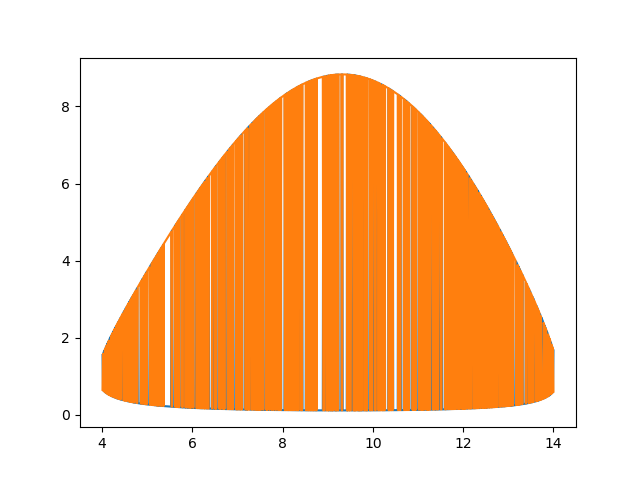

In [105]:
n = 11
k_vals = np.arange(0.01, 10.01, 0.01)+4
#k_vals = np.arange(8.0, 12.01, 0.01)
km = k_vals[int(len(k_vals)//2.9)]
ki = k_vector(km,0)
kj = k_j(ki,n0,n)
lambda_m = 2*np.pi/km
m = m_s(ki,kj,lambda_/8,lambda_/(4*n))[1]
array = np.empty((len(k_vals),2))
for i in range(len(k_vals)):
    k = k_vals[i]
    ki = k_vector(k,0)
    kj = k_j(ki,n0,n)
    m = m_s(ki,kj,lambda_m/8,lambda_m/(4*n))[1]
    array[i] = np.abs(np.linalg.eig(m)[0])
    
plt.figure()
plt.plot(k_vals,array)
plt.show()

In [117]:
k_vals = np.arange(0.01, 10.01, 0.01)
t_vals = np.arange(-2.0, 180.0, .1)
t_valsb = np.arange(-2.0, 85.0, .5)

na = 1.0000001
nb = 1.5
nc = 2.5
ha = .2
hb = .2
hc = .2
ra = 0.01
rb = 0.01
rc = 0.01

ns1 = [na,nb,na]
hs1 = [ha,hb,ha]
rs1 = [ra,rb,ra]
nums1 = [100,50,100]
nums1b = [50,50,50]
colors_med1 = ['blue','red','blue']

ns2 = [na,nb,nc,na]
hs2 = [ha,2*hb,2*hc,ha]
rs2 = [ra,rb,rc,ra]
nums2 = [100,50,50,100]
nums2b = [15,20,20,10]
colors_med2 = ['blue','red','green','blue']

ns3 = [na,nb]
hs3 = [ha,hb]
rs3 = [ra,rb]
nums3 = [100,50]
nums3b = [50,50]
colors_med3 = ['blue','red']

In [11]:
resource.getrusage(resource.RUSAGE_SELF)[2]/1024

149.61328125

In [118]:
%%time
ai_pol_t,bi_pol_t,Ei_3d_t,Hi_3d_t = amps_fields_from_emb_pol_multi_tk(1,k_vals,t_valsb,ns2,hs2,rs2,nums2b)

CPU times: user 30.5 s, sys: 6.67 s, total: 37.2 s
Wall time: 28.6 s


In [ ]:
amps_fields_from_emb_pol_multi_tk(a0_pol,k_values,t_values,refrac_indices,widths,width_ratios,num_elements,k_c=5,sigma=1.5):

In [119]:
resource.getrusage(resource.RUSAGE_SELF)[2]/1024

9964.80078125

## Intensity

In [120]:
step = 5
a_t_pos = ai_pol_t[:,::step]
b_t_pos = bi_pol_t[:,::step]
np.shape(a_t_pos)

(174, 66)

### Plot

In [15]:
#for t in range(len(t_vals)//2):
#    plot_amps(a_t_pos[2*t],b_t_pos[2*t],t_vals[2*t],nums1)

## Momentum Flux

In [25]:
%%time
stt = stress_tensor_t(Ei_3d_t[:,::step],Hi_3d_t[:,::step])
z_mom_flux_t_pos = z_momentum_flux(stt)
f_dens_pos_t = np.diff(z_mom_flux_t_pos,axis=1)
np.shape(f_dens_pos_t)

CPU times: user 1.48 s, sys: 21 ms, total: 1.51 s
Wall time: 1.45 s


(174, 65)

### Plot

In [17]:
#vals0 = np.zeros((len(z_mom_flux_t_pos[0])-1))
#for t in range(len(t_vals)):
#    p = plot_z_momentum(z_mom_flux_t_pos[t],t_vals[t],nums1)
#    vals0=vals0+np.diff(z_mom_flux_t_pos[t])
#    p.plot(vals0)
#    plt.show()
#    plt.close()

## Forces on Interfaces

In [26]:
charges,currents,E_acting,B_acting = surface_charges_currents_t(Ei_3d_t,Hi_3d_t,nums2b,ns2)
L_forces_t = Lorentz_force_t(charges,currents,E_acting,B_acting)
layerforces_t = layer_forces_t(L_forces_t)
np.shape(layerforces_t)

(174, 65)

### Plot

In [19]:
#for t in range(len(t_vals)):
#    plot_vac_forces(vacforces_t[t],t_vals[t],nums2b)

# Animation

In [20]:
def grgr

SyntaxError: expected '(' (1493117214.py, line 1)

## Intensity

### Functions

In [121]:
def generate_plot_amps(ai,bi,time,num_elements,cols=colors,cols_med=colors_med1,top_y=1,bottom_y=0):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(ai),1)
    edgelocs = np.array([0, num_elements[0]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.plot(xvals,np.abs(ai)**2, label='|a|^2')
    plt.plot(xvals,np.abs(bi)**2, label='|b|^2')
    plt.plot(xvals,np.abs(ai+bi)**2, label='|a+b|^2')
    plt.axvline(edges[-1],lw=3,c='k')
    plt.title(f'Intensity Across Layers t = {time:.1f} time units')
    plt.xlabel('Position (layer number)') # A layer starts at the vacuum half before the medium portion
    plt.ylabel('Intensity (arb. units)')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.legend()
    plt.grid()
    return plt.gcf()

def anim_amps(a_t_pos,b_t_pos,t_values,num_elements,cols_med):
    time_frame = len(t_values)
    os.makedirs('anim_amps', exist_ok=True)
    for t in range(time_frame):
        fig = generate_plot_amps(a_t_pos[t],b_t_pos[t],t_values[t],num_elements,cols_med=cols_med)
        fig.savefig(f'anim_amps/plot_amps{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_amps/plot_amps{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_amps/amps_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

In [ ]:
#images = [Image.open(f'anim_amps/plot_amps{t:03d}.png') for t in range(len(t_vals))]
#images[0].save('anim_amps/amps_animation.gif', save_all=True, append_images=images[1:], duration=50, loop=0)

### Execution

In [123]:
delete_content('anim_amps')
anim_amps(a_t_pos,b_t_pos,t_valsb,nums2b,colors_med2)

## Momentum Flux

### Functions

In [ ]:
def generate_plot_sttforcez(f_dens_pos,time,num_elements,vals0,cols_med=colors_med1,top_y=1,bottom_y=-0.6):
    plt.figure(figsize=(10, 4))
    #f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(f_dens_pos),1)+0.5
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.xlabel('Position (layer number)')
    plt.ylabel('Force/Impulse Density (arb. units)')
    plt.title(f'(MST) Z-Force Density on Layers t = {time:.1f} time units')
    plt.plot(xvals,f_dens_pos,label='(MST) Z-Force Density')
    plt.plot(xvals,vals0,label= f'Total Impulse Density at t = {time:.1f} time units')
    plt.axvline(edges[-1],lw=3,c='k')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.legend(loc='upper left')
    plt.grid()
    vals0+=f_dens_pos
    return plt.gcf(),vals0

def anim_sttforcez(f_dens_pos_t,t_values,num_elements,cols_med,top_y=1,bottom_y=-0.6):
    vals0 = np.zeros((len(z_mom_flux_t_pos[0])-1))
    time_frame = len(t_values)
    os.makedirs('anim_sttforcez', exist_ok=True)
    for t in range(time_frame):
        fig,vals0 = generate_plot_sttforcez(f_dens_pos_t[t],t_values[t],num_elements,vals0,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(f'anim_sttforcez/plot_z_force_density{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_sttforcez/plot_z_force_density{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_sttforcez/sttforcez_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
delete_content('anim_sttforcez')
anim_sttforcez(f_dens_pos_t,t_vals,nums2b,colors_med2,top_y=2.0,bottom_y=-2.0)

## Forces on Interfaces

### Functions

In [ ]:
def generate_plot_vac_forces(layerforces,time,num_elements,vals1,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(layerforces),1)+0.5
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'(Lorentz) Z-Force Densities on Layers t = {time:.1f} time units')
    plt.xlabel('Position (layer number)')
    plt.ylabel('Force/Impulse Density (arb. units)')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    plt.plot(xvals,layerforces,c=cols[0],label='(Lorentz) Z-Force Density')
    plt.plot(xvals,vals1,c=cols[1],label= f'Total Impulse Density at t = {time:.1f} time units')
    plt.axvline(edges[-1],c='k')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.grid()
    vals1+=layerforces
    plt.legend()#loc='upper left')
    return plt.gcf(),vals1

def anim_lorentzforcez(layerforces_t,t_values,num_elements,cols_med,top_y=2.0,bottom_y=-2.0):
    time_frame = len(t_values)
    vals1 = np.zeros((np.shape(layerforces_t)[1]))
    os.makedirs('anim_lorentzforcez', exist_ok=True)
    for t in range(time_frame):
        fig,vals1 = generate_plot_vac_forces(layerforces_t[t],t_values[t],num_elements,vals1,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(f'anim_lorentzforcez/plot_lorentzforcez{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_lorentzforcez/plot_lorentzforcez{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_lorentzforcez/lorentzforcez_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
delete_content('anim_lorentzforcez')
anim_lorentzforcez(layerforces_t,t_vals,nums2b,colors_med2)

## Combined 2a

### Functions

In [ ]:
def generate_plot_combined2a(ai,bi,z_mom_flux_pos,time,num_elements,vals0,cols=colors,cols_med=colors_med1,top_y1=1,top_y2=1,bottom_y1=0,bottom_y2=-0.6):
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals1 = np.arange(0,len(ai),1)
    xvals2 = np.arange(0,len(f_dens_pos),1)+0.5
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
        edgelocs = np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys1 = [top_y1,top_y1]
    bottom_ys1 = [bottom_y1,bottom_y1]
    top_ys2 = [top_y2,top_y2]
    bottom_ys2 = [bottom_y2,bottom_y2]
    
    #Amps plot
    axs[0].set_title(f'Intensity Across Layers t = {time} time units')
    #axs[0].set_xlabel('Layer Number')
    axs[0].set_ylabel('Intensity')
    axs[0].set_ylim(bottom_y1-0.02,top_y1+0.02)
    for n in range(len(num_elements)):
        axs[0].fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys1,bottom_ys1,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[0].axvline(loc,ls='--',c='k')
    axs[0].axvline(edges[-1],c='k')
    axs[0].plot(xvals1,np.abs(ai)**2, c=cols[0], label='|a|^2')
    axs[0].plot(xvals1,np.abs(bi)**2, c=cols[1], label='|b|^2')
    axs[0].plot(xvals1,np.abs(ai+bi)**2, c=cols[2], label='|a+b|^2')
    axs[0].legend()
    axs[0].grid()
    
    #Momentum plot
    axs[1].set_title(f'Z-Force Density Across Layers t = {time} time units')
    axs[1].set_xlabel('Layer Number')
    axs[1].set_ylabel('Force Density')
    axs[1].set_ylim(bottom_y2-0.02,top_y2+0.02)
    for n in range(len(num_elements)):
        axs[1].fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys2,bottom_ys2,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[1].axvline(loc,ls='--',c='k')
    axs[1].axvline(edges[-1],c='k')
    axs[1].plot(xvals2,f_dens_pos,c=cols[0], label='Z-Force Density')
    axs[1].plot(xvals2,vals0,c=cols[1],label= f'Total Impulse at t = {time} time units')
    axs[1].legend()
    axs[1].grid()
    
    vals0+=f_dens_pos
    #plt.tight_layout()
    return plt.gcf(),vals0

def anim_combined2a(a_t_pos,b_t_pos,z_mom_flux_t_pos,t_values,num_elements,cols_med):
    vals0 = np.zeros((len(z_mom_flux_t_pos[0])-1))
    time_frame = len(t_values)
    os.makedirs('anim_combined2a', exist_ok=True)
    for t in range(time_frame):
        fig,vals0 = generate_plot_combined2a(a_t_pos[t],b_t_pos[t],z_mom_flux_t_pos[t],t_values[t],num_elements,vals0,cols_med=cols_med)
        fig.savefig(f'anim_combined2a/plot_combined2a{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_combined2a/plot_combined2a{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_combined2a/combined2a_animation.gif', save_all=True, append_images=images[1:], duration=100, loop=0)

### Execution

In [ ]:
delete_content('anim_combined2a')
anim_combined2a(a_t_pos,b_t_pos,z_mom_flux_t_pos,t_vals,nums2b,cols_med=colors_med2)

## Combined 2b

### Functions

In [ ]:
def generate_plot_combined2b(f_dens_pos,layerforces,time,num_elements,vals0,vals1,cols=colors,cols_med=colors_med2,top_y=2,bottom_y=-2):
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    edges = np.cumsum(np.array(num_elements))
    xvals = np.arange(0,len(f_dens_pos),1)+0.5
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
        edgelocs = np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    
    #MST plot
    axs[0].set_title(f'(MST) Z-Force Density Across Layers t = {time:.1f} time units')
    axs[0].set_ylabel('Force/Impulse Density (arb. units)')
    axs[0].set_ylim(bottom_y-0.02,top_y+0.02)
    for n in range(len(num_elements)):
        axs[0].fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[0].axvline(loc,ls='--',c='k')
    axs[0].axvline(edges[-1],lw=3,c='k')
    axs[0].plot(xvals,f_dens_pos,c=cols[0], label='(MST) Z-Force Density')
    axs[0].plot(xvals,vals0,c=cols[1],label= f'Total Impulse Density at t = {time:.1f} time units')
    axs[0].legend()
    axs[0].grid()
    vals0+=f_dens_pos
    
    #Loretz plot
    axs[1].set_title(f'(Lorentz) Z-Force Densities on Layers t = {time:.1f} time units')
    axs[1].set_ylabel('Force/Impulse Density (arb. units)')
    axs[1].set_xlabel('Position (layer number)')
    axs[1].set_ylim(bottom_y-0.02,top_y+0.02)
    for n in range(len(num_elements)):
        axs[1].fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[1].axvline(loc,ls='--',c='k')
    axs[1].axvline(edges[-1],lw=3,c='k')
    axs[1].plot(xvals,layerforces,c=cols[0],label='(Lorentz) Z-Force Density')
    axs[1].plot(xvals,vals1,c=cols[1],label= f'Total Impulse Density at t = {time:.1f} time units')
    axs[1].legend()
    axs[1].grid()
    vals1+=layerforces
    
    return plt.gcf(),vals0,vals1

def anim_combined2b(f_dens_pos_t,layerforces_t,t_values,num_elements,cols_med,top_y=2,bottom_y=-2):
    vals0 = np.zeros((np.shape(f_dens_pos_t)[1]))
    vals1 = np.zeros((np.shape(layerforces_t)[1]))
    time_frame = len(t_values)
    os.makedirs('anim_combined2b', exist_ok=True)
    for t in range(time_frame):
        fig,vals0,vals1 = generate_plot_combined2b(f_dens_pos_t[t],layerforces_t[t],t_values[t],num_elements,vals0,vals1,cols_med=cols_med,top_y=top_y,bottom_y=bottom_y)
        fig.savefig(f'anim_combined2b/plot_combined2b{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_combined2b/plot_combined2b{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_combined2b/combined2b_animation.gif', save_all=True, append_images=images[1:], duration=20, loop=0)

### Execution

In [ ]:
delete_content('anim_combined2b')
anim_combined2b(f_dens_pos_t,layerforces_t,t_vals,nums2b,cols_med=colors_med2)

## Combined 3

### Functions

In [ ]:
def generate_plot_combined3(ai,bi,z_mom_flux_pos,vacforces,time,num_elements,vals0,vals1,cols=colors,cols_med=colors_med1,top_y1=1,bottom_y1=0,top_y2=1.6,bottom_y2=-1.6,top_y3=1.6,bottom_y3=-1.6):
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals1 = np.arange(0,len(ai),1)
    xvals2 = np.arange(0,len(f_dens_pos),1)+0.5
    xvals3 = np.arange(0,len(vacforces),1)+0.5
    edgelocs1 = np.array([0, num_elements[0]])
    edgelocs2 = np.array([0, num_elements[0]-0.5])
    for i in range(len(num_elements)-1):
        edgelocs1 = np.append(edgelocs1, [edges[i],edges[i]+num_elements[i+1]])
        edgelocs2 = np.append(edgelocs2, [edges[i]-0.5,edges[i]-0.5+num_elements[i+1]])
    top_ys1 = [top_y1,top_y1]
    bottom_ys1 = [bottom_y1,bottom_y1]
    top_ys2 = [top_y2,top_y2]
    bottom_ys2 = [bottom_y2,bottom_y2]
    top_ys3 = [top_y3,top_y3]
    bottom_ys3 = [bottom_y3,bottom_y3]
    
    #Amps plot
    axs[0].set_title(f'Intensity Across Layers t = {time} time units')
    #axs[0].set_xlabel('Layer Number')
    axs[0].set_ylabel('Intensity')
    axs[0].set_ylim(bottom_y1-0.02,top_y1+0.02)
    for n in range(len(num_elements)):
        axs[0].fill_between([edgelocs1[2*n],edgelocs1[2*n+1]],top_ys1,bottom_ys1,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[0].axvline(loc,ls='--',c='k')
    axs[0].plot(xvals1,np.abs(ai)**2, c=cols[0], label='|a|^2')
    axs[0].plot(xvals1,np.abs(bi)**2, c=cols[1], label='|b|^2')
    axs[0].plot(xvals1,np.abs(ai+bi)**2, c=cols[2], label='|a+b|^2')
    #axs[0].plot(xvals1,(np.abs(ai)**2-np.abs(bi)**2)/(np.abs(ai)**2+np.abs(bi)**2), c=cols[2], label='(|a|^2-|b|^2)/(|a|^2+|b|^2)')
    axs[0].legend()
    axs[0].grid()
    
    #Momentum plot
    axs[1].set_title(f'Z-Force Density (from MST) Across Layers t = {time} time units')
    #axs[1].set_xlabel('Layer Number')
    axs[1].set_ylabel('Force Density')
    axs[1].set_ylim(bottom_y2-0.02,top_y2+0.02)
    for n in range(len(num_elements)):
        axs[1].fill_between([edgelocs2[2*n],edgelocs2[2*n+1]],top_ys2,bottom_ys2,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[1].axvline(loc-0.5,ls='--',c='k')
    axs[1].plot(xvals2,f_dens_pos,c=cols[0], label='Z-Force Density')
    axs[1].plot(xvals2,vals0,c=cols[1],label= f'Total Impulse at t = {time} time units')
    axs[1].legend()
    axs[1].grid()
    
    axs[2].set_title(f'Lorentz Z-Force Densities on Vacuum Elements Across Layers t = {time} time units')
    axs[2].set_xlabel('Layer Number')
    axs[2].set_ylabel('Force Density')
    for n in range(len(num_elements)):
        axs[2].fill_between([edgelocs1[2*n],edgelocs1[2*n+1]],top_ys3,bottom_ys3,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[2].axvline(loc,ls='--',c='k')
    axs[2].plot(xvals3,vacforces,c=cols[0],label='Z Lorentz Force Density')
    axs[2].plot(xvals3,vals1,c=cols[1],label= f'Total Impulse at t = {time} time units')
    axs[2].set_ylim(bottom_y3-0.02,top_y3+0.02)
    axs[2].grid()
    axs[2].legend()
    
    vals0+=f_dens_pos
    vals1+=vacforces
    
    #plt.tight_layout()
    return plt.gcf(),vals0,vals1

def anim_combined3(a_t_pos,b_t_pos,z_mom_flux_t_pos,vacforces_t,t_values,num_elements,cols_med):
    vals0 = np.zeros((np.shape(z_mom_flux_t_pos)[1]-1))
    vals1 = np.zeros((np.shape(vacforces_t)[1]))
    time_frame = len(t_values)
    os.makedirs('anim_combined3', exist_ok=True)
    for t in range(time_frame):
        fig,vals0,vals1 = generate_plot_combined3(a_t_pos[t],b_t_pos[t],z_mom_flux_t_pos[t],vacforces_t[t],t_values[t],num_elements,vals0,vals1,cols_med=cols_med)
        fig.savefig(f'anim_combined3/plot_combined3{t:03d}.png')
        plt.close(fig)
    images = [Image.open(f'anim_combined3/plot_combined3{t:03d}.png') for t in range(time_frame)]
    images[0].save('anim_combined3/combined3_animation.gif', save_all=True, append_images=images[1:], duration=100, loop=0)

### Execution

In [ ]:
delete_content('anim_combined3')
anim_combined3(a_t_pos,b_t_pos,z_mom_flux_t_pos,vacforces_t,t_vals,nums2b,cols_med=colors_med2)

# What next?

1. Plot forces in green, red, and both over time (integrate z-force density over crystal) and mirror (turn into DBR with 1/4 wavelength of central 2pi/k)
2. Plot "vacuum force" F1 + F2 around vacuum between periods
3. Plot all forces (2*n) and momentum fluxes (not differential)
4. We want mechanical stress due to forces and compare with EM stress

# Mathematica

## Finite structure of 60 periods

In [ ]:
amplis = []
nper = 60
hi = h1
hj = h1
perM = m_s(ki0,k_j(ki0,n0,n1),hi,hj)[1]
stot = MtoS(StoM(interface_s(ki0,k_j(ki0,n0,n0)))@np.linalg.matrix_power(perM,nper)@StoM(interface_s(ki0,k_j(ki0,n0,n0))))
a0 = 1
[b0, an] = stot@np.array([a0, 0])
eg = np.abs(b0)**2 + np.abs(an)**2
print(eg)
amps = np.array([a0, b0])
m = np.eye(2)
amplis.append(amps)
for i in range(nper):
    m = perM@m
    amplis.append(m@amps)
    
amplis = np.array(amplis)

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity') # In the middle between two periods (free space)
plt.title('Intensity Across Layers (back reflection in medium)')
A = np.empty(nper+1)
B = np.empty(nper+1)
A = A.astype(np.complex128)
B = B.astype(np.complex128)
for i in range(nper+1):
    A[i] = amplis[i][0]
    B[i] = amplis[i][1]
plt.plot(np.arange(nper+1),np.abs(A)**2, label = '|A|')
plt.plot(np.arange(nper+1),np.abs(B)**2, label = '|B|')
plt.plot(np.arange(nper+1),np.abs(A+B)**2, label = '|A+B|^2')
plt.grid(True)
plt.legend()
plt.show()

## First 60 periods of an semi-infinite structure

In [ ]:
ev = np.linalg.eig(perM)[1]
#print(ev)
amps = ev[0] # Need some input from the other end to cancel back reflections
m = StoM(interface_s(ki0,k_j(ki0,n0,n0)))
amplis = []
amplis.append(amps)
for i in range(nper):
    m = perM@m
    amplis.append(m@amps)
plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium)')
A = np.empty(nper+1)
B = np.empty(nper+1)
A = A.astype(np.complex128)
B = B.astype(np.complex128)
for i in range(nper+1):
    A[i] = amplis[i][0]
    B[i] = amplis[i][1]
plt.plot(np.arange(nper+1),np.abs(A)**2, label = '|A|')
plt.plot(np.arange(nper+1),np.abs(B)**2, label = '|B|')
plt.plot(np.arange(nper+1),np.abs(A+B)**2, label = '|A+B|^2')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

#plot_amps(*amps_from_a0b0_pol(np.linalg.eig(perM)[1][0],[MtoS(perM)],[60]))

## Embedded structure

In [ ]:
n1a = 1
n2a = 1.1
n1b = 1
n2b = 1.2
kx = .1

ki1 = np.array([kx,0,np.sqrt((2.5**2-kx**2))])
psa = m_s(ki1,k_j(ki1,n1a,n2a),.1,.1)
ppa = m_p(ki1,k_j(ki1,n1a,n2a),.1,.1)
#print(eff_n(ki1,psa[1],.1,.1))
#print(eff_n(ki1,ppa[1],.1,.1))
psb = m_s(ki1,k_j(ki1,n1b,n2b),.1,.1)
ppb = m_p(ki1,k_j(ki1,n1b,n2b),.1,.1)
#print(eff_n(ki1,psb[1],.1,.1))
#print(eff_n(ki1,ppb[1],.1,.1))
elementss = [psa[0],interface_s(ki0,k_j(ki0,n1a,n1b)),psb[0],interface_s(ki0,k_j(ki0,n1b,n1a)),psa[0]]
elementsp = [ppa[0],interface_p(ki0,k_j(ki0,n1a,n1b)),ppb[0],interface_p(ki0,k_j(ki0,n1b,n1a)),ppa[0]]
nums_math = [100,1,50,1,100]

## Fixed left hand side input/output

In [ ]:
emb = embedded_structure(elementss,nums_math)

amps = np.array([[1, 0]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)):
    m = StoM(emb[i])@m
    amps = np.append(amps, [m@(amps[0])], axis=0)

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (back reflection in medium)')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

amps = np.array([np.linalg.eig(psa[1])[1][0]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)-1,-1,-1):
    m = np.linalg.inv(StoM(emb[i]))@m
    amps = np.append(amps, [m@(amps[0])], axis=0)
#print(amps)
amps = amps[-1:0:-1,:]
plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium a)')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

#amps = np.array([np.linalg.eig(psa[1])[1][1]])
#m = np.eye(2)  # Identity matrix
#
#for i in range(len(emb)):
#    m = StoM(emb[i])@m
#    amps = np.append(amps, [m@(amps[0])], axis=0)
#
#amps = amps[::-1]
#
#plt.figure()
#plt.xlabel('Layer Number')
#plt.ylabel('Intensity')
#plt.title('Intensity Across Layers (no back reflection in medium a) Incident from Right')
#plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
#plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
#plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
#plt.legend()
#plt.grid()
#plt.show()

#plot_amps(*amps_from_a0b0_pol([1,0],elementss,nums_math))
#plot_amps(*amps_from_anbn_pol(np.linalg.eig(psa[1])[1][0],elementss,nums_math))

# Graphing

In [ ]:
def periodic_layers(hi,hj,num_layers,top_y=1,bottom_y=0):
    xvals = np.array([0, hj])
    for i in range(num_layers-1):
        xvals = np.append(xvals, [xvals[-1]+hi,xvals[-1]+hi+hj])
    plt.figure()
    plt.xlabel('Position (in units of hj)')
    plt.ylabel('Layer')
    plt.title('Periodic Layer Structure')
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(num_layers):
        plt.fill_between([xvals[2*n]/h1,xvals[2*n+1]/h1], top_ys, bottom_ys, color='blue')
    for x in xvals:
        if x == xvals[0]:
            plt.axvline(x/h1,ls='--',c='k',label='Interface')
        else:
            plt.axvline(x/h1,ls='--',c='k')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
periodic_layers(h1,h1,10)

In [ ]:
edges1 = np.cumsum(np.array(nums1))
xvals = np.arange(0,edges1[-1],1)
edgelocs1 = np.array([0, nums1[0]])
top_ys = [1,1]
bottom_ys = [0,0]
t3d = [33,63,96]
plt.figure(figsize=(8, 3))
for i in range(len(nums1)-1):
     edgelocs1= np.append(edgelocs1, [edges1[i],edges1[i]+nums1[i+1]])
for n in range(len(nums1)):
    plt.fill_between([edgelocs1[2*n],edgelocs1[2*n+1]],top_ys,bottom_ys,color=colors_med[n],alpha=0.2) 
for loc in edges[:-1]:
    plt.axvline(loc,ls='--',c='k')
plt.plot(xvals,np.abs(a_t_pos[33])**2, c=colors[0], label=f'|a|^2 t = {t_vals[33]}')
plt.plot(xvals,np.abs(b_t_pos[33])**2, c=colors[1], label='|b|^2')
plt.plot(xvals,np.abs(a_t_pos[33]+b_t_pos[33])**2, c=colors[2], label='|a+b|^2')

plt.plot(xvals,np.abs(a_t_pos[63])**2, c=colors[0], ls = '-.', label=f'|a|^2 t = {t_vals[63]}')
plt.plot(xvals,np.abs(b_t_pos[63])**2, c=colors[1], ls = '-.', label='|b|^2')
plt.plot(xvals,np.abs(a_t_pos[63]+b_t_pos[63])**2, ls = '-.', c=colors[2], label='|a+b|^2')

plt.plot(xvals,np.abs(a_t_pos[96])**2, c=colors[0], ls = '--', label=f'|a|^2 t = {t_vals[96]}')
plt.plot(xvals,np.abs(b_t_pos[96])**2, c=colors[1], ls = '--', label='|b|^2')
plt.plot(xvals,np.abs(a_t_pos[96]+b_t_pos[96])**2, ls = '--', c=colors[2], label='|a+b|^2')

plt.title(f'Intensity Across Layers')
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.ylim(-0.02,1.02)
plt.legend()
plt.grid()
plt.show()

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    xvals1 = np.arange(0,len(ai),1)
    xvals2 = np.arange(0,len(f_dens_pos),1)+0.5
    edgelocs1 = np.array([0, num_elements[0]])
    edgelocs2 = np.array([0, num_elements[0]-0.5])
    for i in range(len(num_elements)-1):
        edgelocs1 = np.append(edgelocs1, [edges[i],edges[i]+num_elements[i+1]])
        edgelocs2 = np.append(edgelocs2, [edges[i]-0.5,edges[i]-0.5+num_elements[i+1]])
    top_ys1 = [top_y1,top_y1]
    bottom_ys1 = [bottom_y1,bottom_y1]
    top_ys2 = [top_y2,top_y2]
    bottom_ys2 = [bottom_y2,bottom_y2]
    
    #Amps plot
    axs[0].set_title(f'Intensity Across Layers t = {time} time units')
    axs[0].set_xlabel('Layer Number')
    axs[0].set_ylabel('Intensity')
    axs[0].set_ylim(-0.02,1.02)
    for n in range(len(num_elements)):
        axs[0].fill_between([edgelocs1[2*n],edgelocs1[2*n+1]],top_ys1,bottom_ys1,color=colors_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[0].axvline(loc,ls='--',c='k')
    axs[0].plot(xvals1,np.abs(ai)**2, c=colors[0], label='|a|^2')
    axs[0].plot(xvals1,np.abs(bi)**2, c=colors[1], label='|b|^2')
    axs[0].plot(xvals1,np.abs(ai+bi)**2, c=colors[2], label='|a+b|^2')
    axs[0].legend()
    axs[0].grid()
    
    #Momentum plot
    axs[1].set_title(f'Z-Force Density Across Layers t = {time} time units')
    axs[1].set_xlabel('Layer Number')
    axs[1].set_ylabel('Force Density')
    axs[1].set_ylim(-0.62,1.12)
    for n in range(len(num_elements)):
        axs[1].fill_between([edgelocs2[2*n],edgelocs2[2*n+1]],top_ys2,bottom_ys2,color=colors_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        axs[1].axvline(loc-0.5,ls='--',c='k')
    axs[1].plot(xvals2,f_dens_pos,c=colors[0], label='Z-Force Density')
    axs[1].plot(xvals2,vals0,c=colors[1],label= f'Total Impulse at t = {time} time units')
    axs[1].legend(loc='upper left')
    axs[1].grid()
    
    vals0+=f_dens_pos
    plt.tight_layout()
    return plt.gcf(),vals0

In [ ]:
xvals = np.arange(0,len(a_t_pos[0]),1)
#f_dens_pos = np.diff(z_mom_flux_pos)
edges1 = np.cumsum(np.array(nums1))
edgelocs1 = np.array([0, nums1[0]])

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
t3d = [33,63,96]

for t in t3d:
    if t == t3d[0]:
        ax.plot(xvals, np.abs(a_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[0], label='|a|^2')
        ax.plot(xvals, np.abs(b_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[1], label='|a|^2')
        ax.plot(xvals, np.abs(a_t_pos[t]+b_t_pos[t])**2, zs=t_vals[t], c=colors[2], zdir='y', label='|a+b|^2')
    else:
        ax.plot(xvals, np.abs(a_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[0])
        ax.plot(xvals, np.abs(b_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[1])
        ax.plot(xvals, np.abs(a_t_pos[t]+b_t_pos[t])**2, zs=t_vals[t], zdir='y', c=colors[2])
    for loc in edges1[:-1]:
        ax.plot(loc*np.ones((10)), np.linspace(0,1,10), zs=t_vals[t], zdir='y', color='k', linestyle='--', linewidth=1)

# Set labels and title
ax.set_xlabel('Layer Number')
ax.set_ylabel('Time (arb. units)')
ax.set_zlabel('Intensity (arb. units)')
ax.set_title('Intensity Across Layers')

# Add legend
ax.legend()

# Show plot
plt.show()


# Graveyard

## Functions

def k_j_multi(kis,ni,nj):
    kjs = np.transpose(np.array([kis[:,0],kis[:,1],np.sqrt(kis[:,2]**2+np.sum(kis*kis.conj(),axis=1)*((nj/ni)**2-1))]))
    return kjs
    
def k_vector_multi_reflect(k_values,theta=0):
    k_vecs = k_values[:,np.newaxis]*np.array([np.sin(theta),0,-np.cos(theta)])
    return k_vecs

def interface_s(ni,nj,theta=0):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    phi_ij = np.arcsin(ni/nj*np.sin(theta)) # Snell's law
    phi_ji = np.arcsin(nj/ni*np.sin(theta))
    if np.abs(ni/nj*np.sin(theta))>1:
        print("Total internal reflection going ij")
    if np.abs(nj/ni*np.sin(theta))>1:
        print("Total internal reflection going ji")
    rij = (np.cos(theta)-nj/ni*np.cos(phi_ij))/(np.cos(theta)+nj/ni*np.cos(phi_ij)) # Going ij
    rji = (np.cos(theta)-ni/nj*np.cos(phi_ji))/(np.cos(theta)+ni/nj*np.cos(phi_ji)) # Going ji
    #tij = 2.0*np.sin(phi_ij)*np.cos(theta)/np.sin(theta+phi_ij)
    tij = 1+rij
    tji = 1+rji
    #print(np.abs(rij)**2+nj/ni*np.cos(phi_ij)/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+ni/nj*np.cos(phi_ji)/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def interface_s2(ni,nj,theta=0):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    rij = (np.cos(theta)-np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))/(np.cos(theta)+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    rji = (np.cos(theta)-np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))/(np.cos(theta)+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tij = 2.0*np.cos(theta)/(np.cos(theta)+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tji = 2.0*np.cos(theta)/(np.cos(theta)+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    #print(np.abs(rij)**2+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def interface_p(ni,nj,theta=0):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    phi_ij = np.arcsin(ni/nj*np.sin(theta))
    phi_ji = np.arcsin(nj/ni*np.sin(theta))
    if np.abs(ni/nj*np.sin(theta))>1:
        print("Total internal reflection going ij")
    if np.abs(nj/ni*np.sin(theta))>1:
        print("Total internal reflection going ji")
    rij = (nj*np.cos(theta)-ni*np.cos(phi_ij))/(nj*np.cos(theta)+ni*np.cos(phi_ij))
    rji = (ni*np.cos(theta)-nj*np.cos(phi_ji))/(ni*np.cos(theta)+nj*np.cos(phi_ji))
    tij = 2.0*ni*np.cos(theta)/(nj*np.cos(theta)+ni*np.cos(phi_ij))
    tji = 2.0*nj*np.cos(theta)/(ni*np.cos(theta)+nj*np.cos(phi_ji))
    #print(np.abs(rij)**2+nj/ni*np.cos(phi_ij)/np.cos(theta)*np.abs(tij)**2) # Going ij
    #print(np.abs(rji)**2+ni/nj*np.cos(phi_ji)/np.cos(theta)*np.abs(tji)**2) # Going ji
    return np.array([[rij,tji],[tij,rji]])

def interface_p2(ni,nj,theta=0):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    rij = (nj**2*np.cos(theta)-ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))/(nj**2*np.cos(theta)+ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    rji = (ni**2*np.cos(theta)-nj**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))/(ni**2*np.cos(theta)+ni**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    tij = 2.0*ni*nj*np.cos(theta)/(nj**2*np.cos(theta)+ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tji = 2.0*ni*nj*np.cos(theta)/(ni**2*np.cos(theta)+nj**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    #print(np.abs(rij)**2+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def medium(n,lam,h):  # scattering matrix, diagonal terms are reflection coefficients.
    k=2.0*np.pi/lam
    rij=0
    rji=0
    tij=np.exp(1j*n*k*h)
    tji=np.exp(1j*n*k*h)
    return np.array([[rij,tji],[tij,rji]])

def interface_s3(kzi,kzj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_s4(ki,ni,nj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = np.sqrt(kzi**2+np.dot(ki,ki)*((nj/ni)**2-1))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    #print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    #print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_p4(ki,ni,nj):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = np.sqrt(kzi**2+np.dot(ki,ki)*((nj/ni)**2-1))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = ((nj/ni)*kzi - kzj)/((nj/ni)*kzi + kzj)
    rji = -rij
    tij = 2*kzi/((nj/ni)*kzi + (ni/nj)*kzj)
    tji = kzj/kzi * tij # 2*kzj/((ni/nj)*kzj + (nj/ni)*kzi)
    # print(1/kzi*(kzi/ni*np.abs(rij)**2+kzj/nj*np.abs(tij)**2)) # add factors of ni nj figure this out
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def multilayers_m(ki,kj,hi,hj,num_layers):
    M_s = np.linalg.matrix_power(m_s(ki,kj,hi,hj)[1],num_layers)
    M_p = np.linalg.matrix_power(m_p(ki,kj,hi,hj)[1],num_layers)
    return M_s, M_p

def calc_Es_layer(E_amp_vec,n1,theta=0,lam=lam1, h1=h1):
    # s polarised
    layer_s = [interface_s(n0,n1,theta),medium(n1,lam,h1),interface_s(n1,n0,theta)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_amp_vec + E_amp_vec*ref_s
    E2_s = trans_s*E_amp_vec
    print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p(n0,n1,theta),medium(n1,lam,h1),interface_p(n1,n0,theta)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_amp_vec + E_amp_vec*ref_p
    E2_p = trans_p*E_amp_vec
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    return E_amp_vec, E1_s, E2_s, E1_p, E2_p

def calc_Es_layer4(E_avi,ki,nj,ni=n0,h=h1):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #print(E_avsi+E_avpi)
    kj = k_ij(ki,ni,nj)
    # s polarised
    layer_s = [interface_s4(ki,ni,nj),medium4(kj,nj,h),interface_s4(kj,ni,nj)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p4(ki,ni,nj),medium4(kj,nj,h),interface_p4(kj,ni,nj)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi*ref_p
    E2_p = trans_p*E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return E_avi, E1, E2

def calc_Es_layer5(E_avi,ki,nj,ni=n0,h=h1):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #print(E_avsi+E_avpi)
    kj = k_ij(ki,ni,nj)
    # s polarised
    layer_s = [interface_s5(ki,kj),medium4(kj,nj,h),interface_s5(kj,ki)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p5(ki,kj),medium4(kj,nj,h),interface_p5(kj,ki)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi*ref_p
    E2_p = trans_p*E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return E_avi, E1, E2
mapping = {'i': 0, 'sri': 1, 'st': 2, 'pri': 3, 'pt': 4}

def stress_tensor(E_amp_vec, str_input, theta = 0, lam = lam1, n1 = n1, n = n0, mu = mu_0): # Should I add arguments for r_vec and t?
    k_vec = k_vector(theta, lam)
    omega = np.sqrt((c/n)**2*np.dot(k_vec, k_vec))
    E_av = calc_Es_layer(E_amp_vec,n1,theta,lam)[mapping[str_input]]
    H_amp_vec = -1/(mu*omega)*np.cross(k_vec, E_av)
    epsilon = epsilon_0*mu_0/(n**2*mu)
    E_ij = epsilon*np.tensordot(E_av.conj(),E_av,axes=0) - \
    0.5 * epsilon * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = mu*np.tensordot(H_amp_vec.conj(),H_amp_vec,axes=0) - \
    0.5 * mu * np.dot(H_amp_vec.conj(),H_amp_vec) * np.eye(3)
    return E_ij + H_ij

def stress_tensor4(E_avi,ki,nj,str_input,ni=n0,h=h1): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer4(E_avi,ki,nj,ni,h)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    return E_ij + H_ij

def stress_tensor5(E_avi,ki,nj,str_input,ni=n0,h=h1): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer5(E_avi,ki,nj,ni,h)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    return E_ij + H_ij

def show_single_layer(n0,n1,h1):#,width):
    plt.figure()
    plt.xlim(0,11*h1)
    points_per_inch = plt.rcParams['figure.dpi']
    width = (h1 / 2.54) * points_per_inch
    plt.axvline(x=11/2*h1, color='blue', linestyle='-', linewidth = 0.8*width, label = 'Dielectric Medium = ' + str(n1))
    plt.axvline(x=11/2*h1-0.5*h1, color='black', linestyle='-', label = 'Interface 12')
    plt.axvline(x=11/2*h1+0.5*h1, color='black', linestyle='-', label = 'Interface 21')
    plt.plot()
    
def plot_filled_rectangle(rect_width, central_position, rect_height, edgecolor='black', facecolor='lightblue', linewidth=1, label=None):
    left = central_position - rect_width / 2
    bottom = -rect_height/2
    rectangle = patches.Rectangle((left, bottom), rect_width, rect_height, linewidth=linewidth, edgecolor=edgecolor, facecolor=facecolor, label=label)
    plt.gca().add_patch(rectangle)
    
def show_single_layer2(n0,n1,h1,length):
    plt.figure()
    plt.title('Layer system')
    plt.xlabel('Position (m)')
    plt.ylabel('Position (m)')
    plt.xlim(0,length*h1)
    plot_filled_rectangle(h1,length/2*h1,10,label='Dielectric Medium n = ' + str(n1))
    plt.legend()
    plt.show()
    
def multilayers_s(ki,kj,ni,nj,hi,hj,num_layers):
    ls = [interface_s5(ki,kj),medium4(kj,nj,hj),interface_s5(kj,ki)]
    for i in range(num_layers-1):
        ls += [medium4(ki,ni,hi),interface_s5(ki,kj),medium4(kj,nj,hj),interface_s5(kj,ki)]
    return ls

def multilayers_p(ki,kj,ni,nj,hi,hj,num_layers):
    lp = [interface_p5(ki,kj),medium4(kj,nj,hj),interface_p5(kj,ki)]
    for i in range(num_layers-1):
        lp += [medium4(ki,ni,hi),interface_p5(ki,kj),medium4(kj,nj,hj),interface_p5(kj,ki)]
    return lp

def field_n_layer(E_avi,ki,ni,nj,hi,hj,num_layers,f):
    kj = k_j(ki,ni,nj)
    proper_E_avi, proper_E_av_b0, kr = a_0_b_0(E_avi,ki,kj,ni,nj,hi,hj,num_layers)
    M_f_s, M_f_p = multilayers_m(ki,kj,ni,nj,hi,hj,f)
    E_f_s = (M_f_s[0][0] + M_f_s[1][0]) * proper_E_avi[1] + (M_f_s[0][1] + M_f_s[1][1]) * proper_E_av_b0[1]
    E_f_px = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[0] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[0]
    E_f_pz = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[2] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[2]
    E_f = np.array([E_f_px,E_f_s,E_f_pz])
    return E_f

mapping = {'i': 0, 'ri': 1, 't': 2}

def M_eff(mMat):
    e_val, U_T = np.linalg.eig(mMat)
    return U_T

def M_eff1(mMat):
    e_val, U_T = np.linalg.eig(mMat)
    #print(np.product(e_val))
    if np.abs(U_T[0][0]) > np.abs(U_T[1][0]):
        return U_T
    else:
        return np.array([U_T[1],U_T[0]])

def calc_Es_layer6(E_avi,ki,ni,nj,hi,hj,num_layers):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    proper_E_avi = E_avsi + E_avpi
    kj = k_j(ki,ni,nj)
    # s polarised
    layers_s = multilayers_s(ki,kj,ni,nj,hi,hj,num_layers)
    s0_s,t0_s=totalST(layers_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layers_p = multilayers_p(ki,kj,ni,nj,hi,hj,num_layers)
    s0_p,t0_p=totalST(layers_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi * ref_p
    E2_p = trans_p * E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return proper_E_avi, E1, E2

def a_0_b_0(E_avi,ki,Meffs_final,Meffp_final):
    E_avsi, E_avpi = E_avi_decomp(E_avi,ki)
    proper_E_avi = E_avsi + E_avpi
    Seff_s = MtoS(Meffs_final)
    Seff_p = MtoS(Meffp_final)
    if np.abs(Meffs[0][0]) > np.abs(Meffs[1][0]):
        Cs = Meffs[0][0]
    else:
        Cs = Meffs[1][0]
        
    if np.abs(Meffp[0][0]) > np.abs(Meffp[1][0]):
        Cp = Meffp[0][0]
    else:
        Cp = Meffp[1][0]
    proper_E_av_b0 = E_avsi*Cs + E_avpi*Cp
    return proper_E_avi, proper_E_av_b0
    
def amps_from_a0b0_pol(a0b0_proper_pol,elements,num_elements):
    emb = embedded_structure(elements,num_elements)
    aibi_pol = np.array([a0b0_proper_pol])
    m = np.eye(2)
    for i in range(len(emb)):
        m = StoM(emb[i])@m
        aibi_pol = np.append(aibi_pol, [m@(aibi_pol[0])], axis=0)
    ai_pol = aibi_pol[:,0]
    bi_pol = aibi_pol[:,1]
    return ai_pol,bi_pol

def amps_from_anbn_pol(anbn_proper_pol,elements,num_elements):
    emb = embedded_structure(elements,num_elements)
    aibi_pol = np.array([anbn_proper_pol])
    m = np.eye(2)
    for i in range(len(emb)-1,-1,-1):
        m = np.linalg.inv(StoM(emb[i]))@m
        aibi_pol = np.append(aibi_pol, [m@(aibi_pol[0])], axis=0)
    aibi_pol = aibi_pol[-1:0:-1,:]
    ai_pol = aibi_pol[:,0]
    bi_pol = aibi_pol[:,1]
    return ai_pol,bi_pol

def stress_tensor6(E_avi,ki,nj,hi,num_layers,str_input='t',ni=n0,hj=h1,graph=False): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer6(E_avi,ki,ni,nj,hi,hj,num_layers)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    if graph:
        periodic_layers(hi,hj,num_layers)
    return E_ij + H_ij

def z_momentum_layers1(E_avi,ki,nj,hi,num_layers,f):
    pz_as = np.empty(0)
    layers = np.arange(num_layers)
    for n in range(num_layers):
        pz = stress_tensor7(E_avi,ki,nj,hi,n)@norm_vec
        pz_as = np.append(pz_as,np.sqrt(np.dot(pz.conj(),pz)))
    pz_as = pz_as/pz_as[0]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Normal Momentum')
    plt.title('Momentum Over Layers')
    plt.plot(layers,pz_as)
    plt.grid(True)
    plt.show()
    
def field_n_layer(proper_E_avi,proper_E_av_b0,M_f_s,M_f_p):
    E_f_s = (M_f_s[0][0] + M_f_s[1][0]) * proper_E_avi[1] + (M_f_s[0][1] + M_f_s[1][1]) * proper_E_av_b0[1]
    E_f_px = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[0] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[0]
    E_f_pz = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[2] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[2]
    E_f = np.array([E_f_px,E_f_s,E_f_pz])
    return E_f
    
def faux_integration(amps):
    amps_int = np.empty(np.shape(ai_pol_k)[1])
    for i in range(len(amps)):
        amps_int+=amps[i]
    return amps_int
    
def conc_mat(mat,num):
    if num == 1:
        mat_num = np.array([mat])
    else:
        mat_num = np.concatenate(([mat],[mat]))
        for i in range(num-2):
            mat_num = np.array(np.concatenate((mat_num,[mat])))
    return mat_num
    
def element_maker(ki,refrac_indices,widths,width_ratios): #nums
    if len(refrac_indices) != len(widths) or len(widths)!= len(width_ratios):# or len(width_ratios) != len(nums):
        raise ValueError("Input lists must have the same length.")
        return
    elementss = []
    elementsp = []
    neffs = []
    neffp = []
    for i in range(len(refrac_indices)):
        n = refrac_indices[i] #ni,nj = refrac_indices[i]
        w = widths[i]
        r = width_ratios[i]
        kj = k_j(ki,n0,n) #k_j(ki,ni,nj)
        hi = r*w
        hj = (1-r)*w
        ss,ms = m_s(ki,kj,hi,hj)[:2]
        nes = eff_n(ki,ms,hi,hj)
        #ints = interface_s(ki,k_j(ki,n0,n0))
        sp,mp = m_p(ki,kj,hi,hj)[:2]
        nep = eff_n(ki,mp,hi,hj)
        elementss.append(ss)
        elementsp.append(sp)
        neffs.append(nes)
        neffp.append(nep)
    return elementss,neffs,elementsp,neffp
    
def embedded_structure(elements_s_form,num_elements):
    if len(elements_s_form) != len(num_elements):
        raise ValueError("elements_s_form and num_elements must have the same length.")
        return
    emb = 0
    for i in range(len(elements_s_form)):
        if i == 0:
            emb = conc_mat(elements_s_form[i], num_elements[i])
        else:
            emb = np.concatenate((emb, conc_mat(elements_s_form[i], num_elements[i])))
    return emb

def embedded_structure_decomp(elements_decomp_s_form,num_elements):
    if len(elements_decomp_s_form) != len(num_elements):
        raise ValueError("elements_s_form and num_elements must have the same length.")
        return
    emb = 0
    for i in range(len(elements_decomp_s_form)):
        if i == 0:
            emb = np.tile(elements_decomp_s_form[i], (num_elements[i], 1, 1))
        else:
            emb = np.concatenate((emb, np.tile(elements_decomp_s_form[i], (num_elements[i], 1, 1))))
    return emb

def plot_amps(amplis):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    plt.title('Intensity Across Layers (back reflection in medium)')
    plt.plot(np.abs(amplis[:, 0])**2, label='|a|^2')
    plt.plot(np.abs(amplis[:, 1])**2, label='|b|^2')
    plt.plot(np.abs(amplis[:, 0] + amplis[:, 1])**2, label='|a+b|^2')
    plt.legend()
    plt.grid()
    plt.show()
    
def z_momentum_layers(E_avi,ki,f,num_layers=num,ni=n0,nj=n1,hi=h1,hj=h1):
    kj = k_j(ki,ni,nj)
    proper_E_avi, proper_E_av_b0 = a_0_b_0(E_avi,ki,kj,hi,hj,num_layers)
    pz_as = np.empty(0)
    for n in range(f):
        Mfs,Mfp = multilayers_m(ki,kj,hi,hj,n)
        E_n = field_n_layer(proper_E_avi,proper_E_av_b0,Mfs,Mfp)
        pz = stress_tensor_f(E_n,ki)@norm_vec
        pz_as = np.append(pz_as,np.sqrt(np.dot(pz.conj(),pz)))
    pz_as = pz_as/pz_as[0]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Normal Momentum Flux (normalised)')
    plt.title('Momentum Flux Over Layers')
    plt.plot(np.arange(f),pz_as)
    plt.grid(True)
    plt.show()
    
def z_momentum_flux(st_array):
    pz_as = np.empty((len(st_array)),dtype=np.complex128)
    for i in range(len(st_array)):
        pz_as[i] = st_array[i]@norm_vec@norm_vec
    return pz_as

def plot_z_momentum(st_array):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Z-Momentum Flux')
    plt.title('Z-Momentum Flux Across Layers')
    plt.plot(np.diff(z_momentum_flux(st_array)))
    plt.grid()
    plt.show()
    
def mag_field(ki3ds, E_3d_k):
    return -1 / (mu_0 * c * np.sqrt(np.sum(ki3ds * ki3ds.conj(),axis=1)[:,np.newaxis])) * np.cross(ki3ds, E_3d_k)
    
def stress_tensor_pol_multi_k_single_position(a_3d_k,mag_a_3d_k): # Evaluate at a fixed time and position for multiple ks
    E_ij = 0.5 * epsilon_0 * ((a_3d_k[:, :, np.newaxis]).conj()*(a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1) \
    + a_3d_k[:, :, np.newaxis]*((a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1)).conj()) - 0.5 * epsilon_0 \
    * np.eye(3)[np.newaxis, :, :] * np.sum((a_3d_k).conj()*a_3d_k,axis=1)[:, np.newaxis, np.newaxis]
    H_ij = 0.5 * mu_0 * ((mag_a_3d_k[:, :, np.newaxis]).conj()*(mag_a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1) \
    + mag_a_3d_k[:, :, np.newaxis]*((mag_a_3d_k[:, :, np.newaxis]).transpose(0, 2, 1)).conj()) - 0.5 * mu_0 \
    * np.eye(3)[np.newaxis, :, :] * np.sum((mag_a_3d_k).conj()*mag_a_3d_k,axis=1)[:, np.newaxis, np.newaxis]
    return E_ij+H_ij

def stress_tensor_pol_multi_k(ai_pol_k,bi_pol_k,k_values,theta=0):
    ks_len,pos_len = np.shape(ai_pol_k)
    st_pol_k_pos = np.empty((ks_len,pos_len,3,3),dtype=np.complex128)
    for i in range(pos_len):
        a = sto3d(ai_pol_k[:,i])
        b = sto3d(bi_pol_k[:,i])
        H_a = mag_field(k_vector_multi(k_vals,theta), a)
        H_b = mag_field(k_vector_multi_reflect(k_vals,theta), b)
        st_pol_k_pos[:,i] = stress_tensor_pol_multi_k_single_position(a+b,H_a+H_b)
    return st_pol_k_pos

def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    t_len,ks_len,pos_len = np.shape(ai_pol_tk)
    st_pol_tk = np.empty((t_len,ks_len,pos_len,3,3),dtype=np.complex128)
    for t in range(t_len):
        st_pol_tk[t] = stress_tensor_pol_multi_k(ai_pol_tk[t],bi_pol_tk[t],k_values,theta)
    return st_pol_tk
    
def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
    bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
    H_ai_3d_multi_tk = mag_field_tk(k_values,ai_3d_multi_tk,theta)
    H_bi_3d_multi_tk = mag_field_tk_rev(k_values,bi_3d_multi_tk,theta)
    ai_3d_multi_t = np.sum(ai_3d_multi_tk,axis=1)
    bi_3d_multi_t = np.sum(bi_3d_multi_tk,axis=1)
    H_ai_3d_multi_t = np.sum(H_ai_3d_multi_tk,axis=1)
    H_bi_3d_multi_t = np.sum(H_bi_3d_multi_tk,axis=1)
    E_field = ai_3d_multi_t+bi_3d_multi_t
    H_field = H_ai_3d_multi_t+H_bi_3d_multi_t
    E_cross_terms = 0.5 * epsilon_0 * (np.einsum('...i,...j->...ij', E_field, E_field.conj()) \
                            + np.einsum('...i,...j->...ij', E_field.conj(), E_field))
    E_mag = 0.5 * epsilon_0 * np.einsum('...i,...i->...', E_field, E_field.conj())
    E_mag_id = np.einsum('...,jk->...jk', E_mag, np.eye(3))
    H_cross_terms = 0.5 * mu_0 * (np.einsum('...i,...j->...ij', H_field, H_field.conj()) \
                            + np.einsum('...i,...j->...ij', H_field.conj(), H_field))
    H_mag = 0.5 * mu_0 * np.einsum('...i,...i->...', H_field, H_field.conj())
    H_mag_id = np.einsum('...,jk->...jk', H_mag, np.eye(3))
    return E_cross_terms-E_mag_id+H_cross_terms-H_mag_id
    
def stress_tensor_pol_multi_tk3(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    ai_3d_multi_tk = sto3d_multi_tk(ai_pol_tk)
    bi_3d_multi_tk = sto3d_multi_tk(bi_pol_tk)
    H_ai_3d_multi_tk = mag_field_tk(k_values,ai_3d_multi_tk,theta)
    H_bi_3d_multi_tk = mag_field_tk_rev(k_values,bi_3d_multi_tk,theta)
    E_field = ai_3d_multi_tk+bi_3d_multi_tk
    H_field = H_ai_3d_multi_tk+H_bi_3d_multi_tk
    E_cross_terms = 0.5 * epsilon_0 * (np.einsum('...i,...j->...ij', E_field, E_field.conj()) \
                            + np.einsum('...i,...j->...ij', E_field.conj(), E_field))
    E_mag = 0.5 * epsilon_0 * np.einsum('...i,...i->...', E_field, E_field.conj())
    E_mag_id = np.einsum('...,jk->...jk', E_mag, np.eye(3))
    H_cross_terms = 0.5 * mu_0 * (np.einsum('...i,...j->...ij', H_field, H_field.conj()) \
                            + np.einsum('...i,...j->...ij', H_field.conj(), H_field))
    H_mag = 0.5 * mu_0 * np.einsum('...i,...i->...', H_field, H_field.conj())
    H_mag_id = np.einsum('...,jk->...jk', H_mag, np.eye(3))
    return E_cross_terms-E_mag_id+H_cross_terms-H_mag_id
    
def stress_tensor_pol_multi_tk2(Ei_3d_multi_tk,Hi_3d_multi_tk):
    t_len,ks_len,pos_len = np.shape(Ei_3d_multi_tk)[:3]
    st_pol_t_pos = np.empty((t_len,pos_len,3,3),dtype=np.complex128)
    Ei_3d_t_pos = np.sum(Ei_3d_multi_tk,axis=1)
    Hi_3d_t_pos = np.sum(Hi_3d_multi_tk,axis=1)
    for t in range(t_len):
        Ei_3d_pos = Ei_3d_t_pos[t]
        Hi_3d_pos = Hi_3d_t_pos[t]
        for p in range(pos_len):
            st_pol_t_pos[t][p] = stress_tensor(Ei_3d_pos[p],Hi_3d_pos[p])
    return st_pol_t_pos
    
def sto3d_multi_tk2(ai_pol_tk):
    t_len,ks_len,pos_len = np.shape(ai_pol_tk)
    sto3d_multi = np.empty((t_len,ks_len,pos_len,3),dtype=np.complex128)
    for t in range(t_len):
        ai_pol_k_pos = ai_pol_tk[t]
        for k in range(ks_len):
            sto3d_multi[t][k] = sto3d(ai_pol_k_pos[k])
    return sto3d_multi
    
def mag_field_tk(k_values, Ei_3d_multi_tk,theta=0):
    u_dir = np.array([np.sin(theta),0,np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    ki3ds_reshaped = np.expand_dims(ki3ds, axis=0)
    shape = np.shape(Ei_3d_multi_tk)
    ki3ds_broadcasted = np.tile(ki3ds_reshaped, (shape[0],shape[2], 1, 1))
    ki3ds_broadcasted_swapped = np.swapaxes(ki3ds_broadcasted, 1, 2)
    cross_product = np.cross(ki3ds_broadcasted_swapped,Ei_3d_multi_tk)
    return -1 / (mu_0 * c) * np.einsum('j,ijkl->ijkl', 1/k_values, cross_product)

def mag_field_tk_rev(k_values, Ei_3d_multi_tk,theta=0):
    u_dir = np.array([np.sin(theta),0,-np.cos(theta)],dtype=np.complex128)
    ki3ds = np.einsum('i,j->ij',k_values,u_dir)
    ki3ds_reshaped = np.expand_dims(ki3ds, axis=0)
    shape = np.shape(Ei_3d_multi_tk)
    ki3ds_broadcasted = np.tile(ki3ds_reshaped, (shape[0],shape[2], 1, 1))
    ki3ds_broadcasted_swapped = np.swapaxes(ki3ds_broadcasted, 1, 2)
    cross_product = np.cross(ki3ds_broadcasted_swapped,Ei_3d_multi_tk)
    return -1 / (mu_0 * c) * np.einsum('j,ijkl->ijkl', 1/k_values, cross_product)
    
def stress_tensor_pol_multi_tk(ai_pol_tk,bi_pol_tk,k_values,theta=0):
    t_len,ks_len,pos_len = np.shape(ai_pol_tk)
    st_pol_t_pos = np.empty((t_len,pos_len,3,3),dtype=np.complex128)
    for t in range(t_len):
        ai_pol_k = ai_pol_tk[t]
        bi_pol_k = bi_pol_tk[t]
        for p in range(pos_len):
            a_k = sto3d(ai_pol_k[:,p])
            b_k = sto3d(bi_pol_k[:,p])
            H_a_k = mag_field(k_vals, a_k, theta)
            H_b_k = mag_field_rev(k_vals, b_k, theta)
            a_pos = np.sum(a_k,axis=0)
            b_pos = np.sum(b_k,axis=0)
            H_a_pos = np.sum(H_a_k,axis=0)
            H_b_pos = np.sum(H_b_k,axis=0)
            st_pol_t_pos[t][p] = stress_tensor(a_pos+b_pos,H_a_pos+H_b_pos)
    return st_pol_t_pos

def sto3d(ai_pol):
    ai_3d = np.transpose(np.array([np.zeros(len(ai_pol)),ai_pol,np.zeros(len(ai_pol))]))
    return ai_3d

def pxto3d(ai_pol):
    ai_3d = np.transpose(np.array([ai_pol,np.zeros(len(ai_pol)),np.zeros(len(ai_pol))]))
    return ai_3d

def pzto3d(ai_pol):
    ai_3d = np.transpose(np.array([np.zeros(len(ai_pol)),np.zeros(len(ai_pol)),ai_pol]))
    return ai_3d

def amps_from_els_3d(a0_3d,ki,s_elements,p_elements,num_elements):
    [a0px,a0s,a0pz] = E_avi_decomp(a0_3d,ki)[0]+E_avi_decomp(a0_3d,ki)[1] #a0_proper_3d 
    aipx,bipx = amps_from_els_pol(a0px,p_elements,num_elements)
    ais,bis = amps_from_els_pol(a0s,s_elements,num_elements)
    aipz,bipz = amps_from_els_pol(a0pz,p_elements,num_elements)
    ai_3d = np.transpose(np.array([aipx,ais,aipz]))
    bi_3d = np.transpose(np.array([bipx,bis,bipz]))
    return ai_3d,bi_3d

def plot_amps_3d(ai_3d,bi_3d):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    plt.title('Intensity Across Layers')
    plt.plot(np.abs(ai_3d[:,0])**2+np.abs(ai_3d[:,1])**2+np.abs(ai_3d[:,2])**2, label='|a|^2')
    plt.plot(np.abs(bi_3d[:,0])**2+np.abs(bi_3d[:,1])**2+np.abs(bi_3d[:,2])**2, label='|b|^2')
    plt.plot(np.abs(ai_3d[:,0]+bi_3d[:,0])**2+np.abs(ai_3d[:,1]+bi_3d[:,1])**2+np.abs(ai_3d[:,2]+bi_3d[:,2])**2, label='|a+b|^2')
    plt.legend()
    plt.grid()
    plt.show()

## Miscellaneous remains

def M_eff(ki,kj,hi,hj,num_layers):
    ms = m_s(ki,kj,hi,hj)
    mp = m_p(ki,kj,hi,hj)
    M_s, M_p = multilayers_m(ki,kj,hi,hj,num_layers)
    e_val_s, U_T_s = np.linalg.eig(ms)
    e_val_p, U_T_p = np.linalg.eig(mp)
    # Recompose original matrix as UT lam U to test
    # Check np.matrixpower
    return [e_val_s,U_T_s],[e_val_p,U_T_p],[M_s, M_p]

ms = m_s(ki0,k_j(ki0,n0,n1),h1,h1)
evp, P = np.linalg.eig(ms)
evp = np.diag(evp)
Dp = np.linalg.matrix_power(evp, num)
M_s = np.linalg.matrix_power(ms, num)
evp1, P1 = np.linalg.eig(M_s)
print(P)
print(P1)

Dns - Dnp

[e_val_s,U_T_s],[e_val_p,U_T_p],[M_s, M_p] = M_eff(ki0,k_j(ki0,n0,n1),h1,h1,num)

evs = np.diag(e_val_s)
evp = np.diag(e_val_p)

Us = np.linalg.inv(U_T_s)
Up = np.linalg.inv(U_T_p)

Dns = np.linalg.matrix_power(evs, num)
Dnp = np.linalg.matrix_power(evp, num)

reconstructed_Ms = np.dot(np.dot(U_T_s,Dns),Us)
print(M_s)
print(reconstructed_Ms)

print(np.allclose(reconstructed_Ms,M_s))

reconstructed_Mp = np.dot(np.dot(U_T_p,Dnp),Up)
print(M_p)
print(reconstructed_Mp)

print(np.allclose(reconstructed_Mp,M_p))